In [3]:
import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import pprint
import json
import os
import yaml
from ipywidgets import widgets
import pyarrow.parquet as pq
from net2brain.evaluations.plotting import Plotting
from net2brain.evaluations.rsa import RSA
from scipy.stats import false_discovery_control


In [5]:
available_dirs = os.listdir('results')
print(available_dirs)

results_dropdown = widgets.Dropdown(
    options=available_dirs,
    disabled=False,
)

display(results_dropdown)

['resnet50_t=15_gs=224_7c077e46', 'resnet50_t=0_gs=224_c55ac28d']


Dropdown(options=('resnet50_t=15_gs=224_7c077e46', 'resnet50_t=0_gs=224_c55ac28d'), value='resnet50_t=15_gs=22…

In [6]:
results_dir = results_dropdown.value
print(results_dir)

resnet50_t=15_gs=224_7c077e46


In [7]:
rsa_df_path = os.path.join("results",results_dir, "eval_df_rsa.parquet")
reg_df_path = os.path.join("results",results_dir, "eval_df_reg.parquet")

# FDR correction and inspection of raw numbers

In [8]:
rsa_table = pq.read_table(rsa_df_path, partitioning=None)
rsa_df = rsa_table.to_pandas()
rsa_df

,ROI,Layer,Model,R,%R,R_array,Significance,SEM,LNC,UNC
0,V3d_lh,backbone.layer1,resnet50_t=15_gs=224_7c077e46,0.034675,41.932200,"[0.041957982757712974, 0.04050701720067326, 0....",3.436294e-05,0.003727,0.082692,0.244442
1,V3d_lh,backbone.layer2,resnet50_t=15_gs=224_7c077e46,0.045047,54.475415,"[0.060461803845533096, 0.05640321217067803, 0....",2.683433e-05,0.004663,0.082692,0.244442
2,V3d_lh,backbone.layer3,resnet50_t=15_gs=224_7c077e46,0.073272,88.608315,"[0.08902647747842223, 0.0860104705992747, 0.04...",2.578534e-05,0.007538,0.082692,0.244442
3,V3d_lh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.082870,100.214868,"[0.09531448367729506, 0.0957981347276964, 0.05...",2.074026e-05,0.008248,0.082692,0.244442
4,PPA_lh,backbone.layer1,resnet50_t=15_gs=224_7c077e46,0.066304,39.037532,"[0.07402329049008409, 0.07237556176434029, 0.0...",7.358257e-06,0.005647,0.169846,0.329043
...,...,...,...,...,...,...,...,...,...,...
131,V2d_rh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.090244,77.850144,"[0.11283427975604676, 0.08871006102820944, 0.0...",2.435955e-06,0.006524,0.115920,0.279621
132,EBA_rh,backbone.layer1,resnet50_t=15_gs=224_7c077e46,0.050744,13.142384,"[0.05316839707556583, 0.05281814392061043, 0.0...",9.490912e-07,0.003194,0.386108,0.505474
133,EBA_rh,backbone.layer2,resnet50_t=15_gs=224_7c077e46,0.057313,14.843767,"[0.060000675546680565, 0.06156255873975616, 0....",7.021926e-07,0.003452,0.386108,0.505474
134,EBA_rh,backbone.layer3,resnet50_t=15_gs=224_7c077e46,0.097130,25.156102,"[0.10165201661795172, 0.10474061236321171, 0.1...",8.817444e-07,0.006048,0.386108,0.505474


In [9]:
meta_rsa = rsa_table.schema.metadata["custom_meta".encode()]
meta_rsa = json.loads(meta_rsa)
pprint.pp(meta_rsa)

{'directory': '../data/central_vision_ssl',
 'name': 'resnet50',
 'time_window': 15,
 'crop_size': 224,
 'center_crop': False,
 'layers': ['backbone.layer1',
            'backbone.layer2',
            'backbone.layer3',
            'backbone.layer4'],
 'evaluation': 'rsa'}


In [10]:
rsa_df_fdr = rsa_df.copy()
rsa_df_fdr["Significance"] = false_discovery_control(rsa_df_fdr["Significance"].to_numpy())
rsa_df_fdr

,ROI,Layer,Model,R,%R,R_array,Significance,SEM,LNC,UNC
0,V3d_lh,backbone.layer1,resnet50_t=15_gs=224_7c077e46,0.034675,41.932200,"[0.041957982757712974, 0.04050701720067326, 0....",0.000049,0.003727,0.082692,0.244442
1,V3d_lh,backbone.layer2,resnet50_t=15_gs=224_7c077e46,0.045047,54.475415,"[0.060461803845533096, 0.05640321217067803, 0....",0.000039,0.004663,0.082692,0.244442
2,V3d_lh,backbone.layer3,resnet50_t=15_gs=224_7c077e46,0.073272,88.608315,"[0.08902647747842223, 0.0860104705992747, 0.04...",0.000039,0.007538,0.082692,0.244442
3,V3d_lh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.082870,100.214868,"[0.09531448367729506, 0.0957981347276964, 0.05...",0.000034,0.008248,0.082692,0.244442
4,PPA_lh,backbone.layer1,resnet50_t=15_gs=224_7c077e46,0.066304,39.037532,"[0.07402329049008409, 0.07237556176434029, 0.0...",0.000014,0.005647,0.169846,0.329043
...,...,...,...,...,...,...,...,...,...,...
131,V2d_rh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.090244,77.850144,"[0.11283427975604676, 0.08871006102820944, 0.0...",0.000006,0.006524,0.115920,0.279621
132,EBA_rh,backbone.layer1,resnet50_t=15_gs=224_7c077e46,0.050744,13.142384,"[0.05316839707556583, 0.05281814392061043, 0.0...",0.000004,0.003194,0.386108,0.505474
133,EBA_rh,backbone.layer2,resnet50_t=15_gs=224_7c077e46,0.057313,14.843767,"[0.060000675546680565, 0.06156255873975616, 0....",0.000003,0.003452,0.386108,0.505474
134,EBA_rh,backbone.layer3,resnet50_t=15_gs=224_7c077e46,0.097130,25.156102,"[0.10165201661795172, 0.10474061236321171, 0.1...",0.000004,0.006048,0.386108,0.505474


In [11]:
reg_table = pq.read_table(reg_df_path, partitioning=None)
reg_df = reg_table.to_pandas()
reg_df

,ROI,Layer,Model,R,%R,R_array,Significance,SEM,LNC,UNC
0,V1d_lh,backbone.layer1,resnet50_t=15_gs=224_7c077e46,0.401678,NaN,"[0.48290517174272746, 0.4704377846506375, 0.41...",3.479667e-07,0.021839,NaN,NaN
1,V1d_lh,backbone.layer2,resnet50_t=15_gs=224_7c077e46,0.422130,NaN,"[0.4915115930745722, 0.5022386010274059, 0.429...",1.790009e-07,0.020838,NaN,NaN
2,V1d_lh,backbone.layer3,resnet50_t=15_gs=224_7c077e46,0.426128,NaN,"[0.5037227022065579, 0.5073988363010288, 0.420...",1.503748e-07,0.020511,NaN,NaN
3,V1d_lh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.397199,NaN,"[0.458649625936526, 0.4816535787289696, 0.3822...",1.653129e-07,0.019383,NaN,NaN
0,mfs-words_lh,backbone.layer1,resnet50_t=15_gs=224_7c077e46,0.163741,NaN,"[0.12973298741796974, 0.21190323580291567, 0.1...",4.217676e-05,0.018162,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
3,PPA_lh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.421222,NaN,"[0.41867805186506196, 0.5610072401288139, 0.37...",7.054476e-06,0.035650,NaN,NaN
0,VWFA-1_lh,backbone.layer1,resnet50_t=15_gs=224_7c077e46,0.166999,NaN,"[0.17879350189601287, 0.2104067676428554, 0.12...",2.607645e-04,0.024676,NaN,NaN
1,VWFA-1_lh,backbone.layer2,resnet50_t=15_gs=224_7c077e46,0.195262,NaN,"[0.2107298793196419, 0.26402902612048934, 0.14...",2.089336e-04,0.027839,NaN,NaN
2,VWFA-1_lh,backbone.layer3,resnet50_t=15_gs=224_7c077e46,0.240858,NaN,"[0.25810697940530725, 0.32921872857895723, 0.1...",1.818486e-04,0.033584,NaN,NaN


In [12]:
meta_reg = reg_table.schema.metadata["custom_meta".encode()]
meta_reg = json.loads(meta_reg)
pprint.pp(meta_reg)

{'directory': '../data/central_vision_ssl',
 'name': 'resnet50',
 'time_window': 15,
 'crop_size': 224,
 'center_crop': False,
 'layers': ['backbone.layer1',
            'backbone.layer2',
            'backbone.layer3',
            'backbone.layer4'],
 'evaluation': 'reg'}


In [13]:
reg_df_fdr = reg_df.copy()
reg_df_fdr["Significance"] = false_discovery_control(reg_df_fdr["Significance"].to_numpy())
reg_df_fdr

,ROI,Layer,Model,R,%R,R_array,Significance,SEM,LNC,UNC
0,V1d_lh,backbone.layer1,resnet50_t=15_gs=224_7c077e46,0.401678,NaN,"[0.48290517174272746, 0.4704377846506375, 0.41...",0.000002,0.021839,NaN,NaN
1,V1d_lh,backbone.layer2,resnet50_t=15_gs=224_7c077e46,0.422130,NaN,"[0.4915115930745722, 0.5022386010274059, 0.429...",0.000001,0.020838,NaN,NaN
2,V1d_lh,backbone.layer3,resnet50_t=15_gs=224_7c077e46,0.426128,NaN,"[0.5037227022065579, 0.5073988363010288, 0.420...",0.000001,0.020511,NaN,NaN
3,V1d_lh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.397199,NaN,"[0.458649625936526, 0.4816535787289696, 0.3822...",0.000001,0.019383,NaN,NaN
0,mfs-words_lh,backbone.layer1,resnet50_t=15_gs=224_7c077e46,0.163741,NaN,"[0.12973298741796974, 0.21190323580291567, 0.1...",0.000051,0.018162,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
3,PPA_lh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.421222,NaN,"[0.41867805186506196, 0.5610072401288139, 0.37...",0.000013,0.035650,NaN,NaN
0,VWFA-1_lh,backbone.layer1,resnet50_t=15_gs=224_7c077e46,0.166999,NaN,"[0.17879350189601287, 0.2104067676428554, 0.12...",0.000267,0.024676,NaN,NaN
1,VWFA-1_lh,backbone.layer2,resnet50_t=15_gs=224_7c077e46,0.195262,NaN,"[0.2107298793196419, 0.26402902612048934, 0.14...",0.000217,0.027839,NaN,NaN
2,VWFA-1_lh,backbone.layer3,resnet50_t=15_gs=224_7c077e46,0.240858,NaN,"[0.25810697940530725, 0.32921872857895723, 0.1...",0.000190,0.033584,NaN,NaN


# Inspecting RSA and linear Encoding results

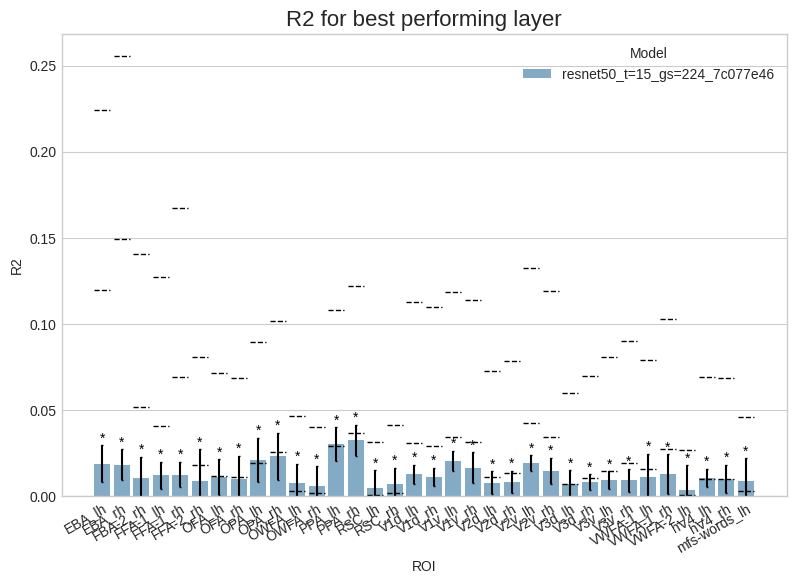

In [14]:
from net2brain.evaluations.plotting import Plotting

plotter = Plotting([rsa_df_fdr])
rsa_best_layer_df = plotter.plot()

IndexError: list index out of range

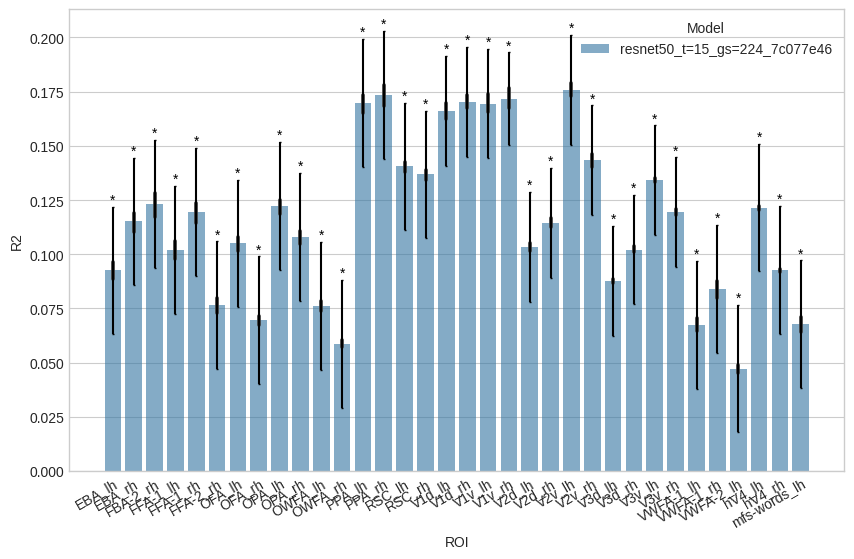

In [15]:
plotter = Plotting([reg_df_fdr])
reg_best_layer_df = plotter.plot()

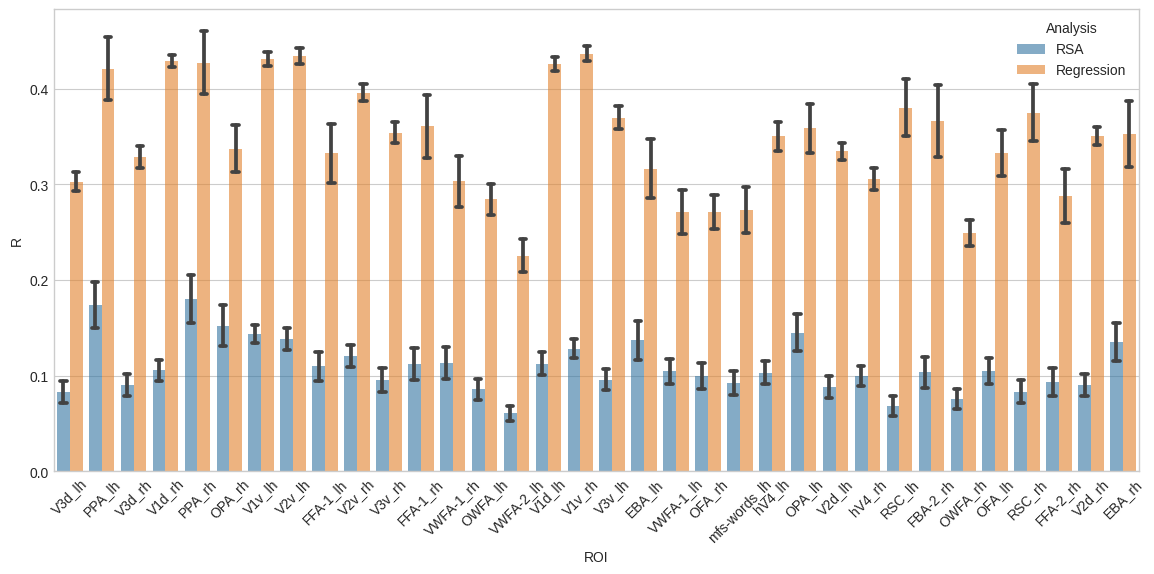

In [16]:
plot_rsa = rsa_df_fdr.copy()
plot_rsa["Analysis"] = "RSA"
plot_reg = reg_df_fdr.copy()
plot_reg["Analysis"] = "Regression"
plot_df = pd.concat([plot_rsa, plot_reg])

plt.figure(figsize=(14,6))

ax = sns.barplot(plot_df, x="ROI", y="R", hue="Analysis", estimator = np.max, alpha=0.6, errorbar='se', capsize=0.2)
ax.tick_params(axis='x', labelrotation=45)


# Model comparison RSA

In [17]:
results_dropdown_1 = widgets.Dropdown(
    options=available_dirs,
    disabled=False,
)

display(results_dropdown_1)


results_dropdown_2 = widgets.Dropdown(
    options=available_dirs,
    disabled=False,
)

display(results_dropdown_2)

Dropdown(options=('resnet50_t=15_gs=224_7c077e46', 'resnet50_t=0_gs=224_c55ac28d'), value='resnet50_t=15_gs=22…

Dropdown(options=('resnet50_t=15_gs=224_7c077e46', 'resnet50_t=0_gs=224_c55ac28d'), value='resnet50_t=15_gs=22…

In [26]:
results_dir_1 = results_dropdown_1.value
print(results_dir_1)
results_dir_2 = results_dropdown_2.value
print(results_dir_2)

resnet50_t=15_gs=224_7c077e46
resnet50_t=0_gs=224_c55ac28d


In [19]:
with open(os.path.join("results",results_dir_1, "config.yaml"), 'r') as f:
    config_1 = yaml.safe_load(f)
with open(os.path.join("results",results_dir_2, "config.yaml"), 'r') as f:
    config_2 = yaml.safe_load(f)

rdm_path_1 = "tmp/rdms/" + results_dir_1 + "_rdm"
rdm_path_2 = "tmp/rdms/" + results_dir_2 + "_rdm"
brain_rdms = config_1["data"]["brain_rdms"]

In [20]:
from net2brain.evaluations.distance_functions import registered_distance_functions
evaluation_1 = RSA(rdm_path_1, brain_rdms, model_name=config_1["model"]["name"], squared=False)
#evaluation_1.distance_metric = "spearman"
#evaluation_1.distance = registered_distance_functions[evaluation_1.distance_metric]
evaluation_2 = RSA(rdm_path_2, brain_rdms, model_name=config_2["model"]["name"], squared=False)
#evaluation_2.distance_metric = "spearman"
#evaluation_2.distance = registered_distance_functions[evaluation_2.distance_metric]

evaluation_1.evaluate()
evaluation_2.evaluate()

KeyboardInterrupt: 

In [27]:
table1 = pq.read_table(os.path.join("results", results_dir_1, "eval_df_rsa.parquet"), partitioning=None)
table2 = pq.read_table(os.path.join("results", results_dir_2, "eval_df_rsa.parquet"), partitioning=None)

dataframe1 = table1.to_pandas()
dataframe2 = table2.to_pandas()

In [28]:
with open(os.path.join("results",results_dir_1, "RSA_instance.pkl"), 'rb') as f:
    evaluation_1 = pickle.load(f)

with open(os.path.join("results",results_dir_2, "RSA_instance.pkl"), 'rb') as f:
    evaluation_2 = pickle.load(f)

In [ ]:
ttest, sig_pairs = evaluation_1.compare_model(evaluation_2)



NameError: name 'ra' is not defined

In [36]:
sig_pairs_renamed = []
for pair in sig_pairs:
    new_name = pair[0][0].split(") ")[1]
    new_name = new_name.split("_RDMs")[0]
    new_pair = [(new_name,  pair[0][1]), (new_name, pair[1][1])]
    sig_pairs_renamed.append(new_pair)

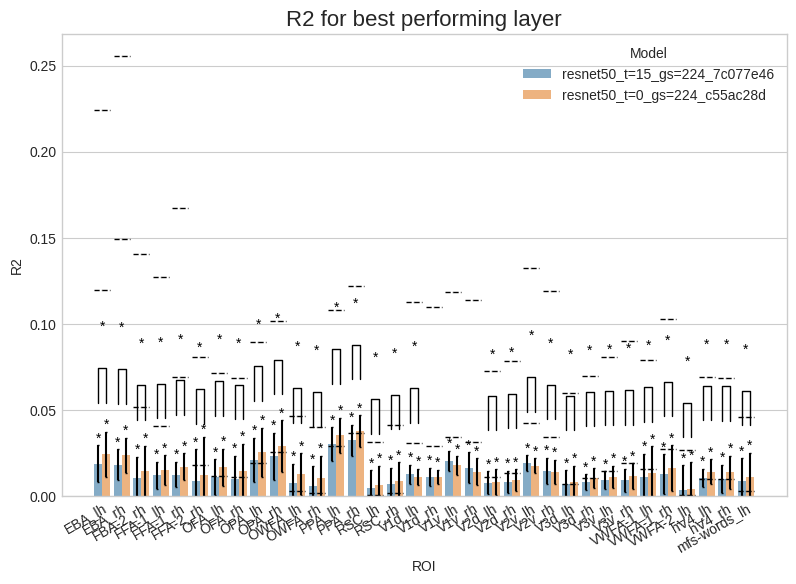

In [37]:
# Plotting with significance
plotter = Plotting([dataframe1, dataframe2])
results_dataframe = plotter.plot(pairs=sig_pairs_renamed)

# Models side-by-side Regression

In [39]:
table1 = pq.read_table(os.path.join("results", results_dir_1, "eval_df_reg.parquet"), partitioning=None)
table2 = pq.read_table(os.path.join("results", results_dir_2, "eval_df_reg.parquet"), partitioning=None)

dataframe1 = table1.to_pandas()
dataframe2 = table2.to_pandas()

IndexError: list index out of range

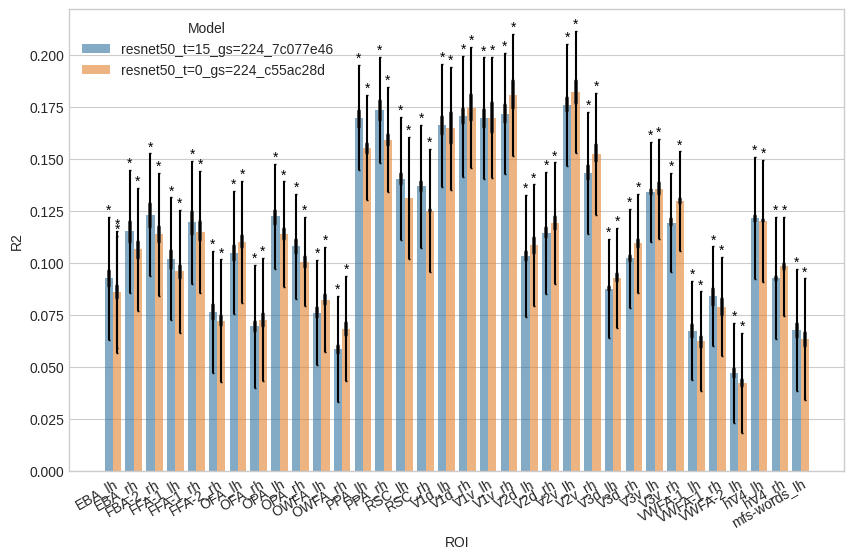

In [40]:
plotter = Plotting([dataframe1,dataframe2])
results_dataframe = plotter.plot()